Processed data is stored in pkl file<br>
Load data and fit with PyMC<br>
Pt100 KOH CO oxidation<br>

**Models:**<br> 

ER:<br> 
1. CO + * -> CO*<br> 
2. CO* + OH- -> COOH* + e-<br> 
3. COOH* + OH- -> CO2 + H2O + * + e-<br>
4. OH- + * -> OH* + e-<br>

LH: <br>
1. CO + * -> CO*<br>
2. CO* + OH* -> COOH* + *<br> 
3. COOH* + OH- -> CO2 + H2O + * + e-<br>
4. OH- + * -> OH* + e-<br>

Updates: 
1. ER_3 eliminated for bad fits. 
2. LH_3 eliminated for bad fits. 
3. LH_2 eliminated for bad fits. 
4. ER_2 looks good. 
5. ER_2_3: KO rhat
6. ER_LH_2: KO divergences
7. ER_LH_2_3: KO rhat (+ divergences rate)

# Initialization - Rate only

In [1]:
import numpy as np
import pymc as pm
import arviz as az
import pandas as pd
import xarray as xr
import pickle 
import nutpie
import matplotlib.pyplot as plt
import pytensor.tensor as pt
import itertools

plt.rcParams['figure.dpi'] = 60
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

# Experimental conditions and constants 
C_KOH_list = np.array([0.1, 0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm
conditions = list(itertools.product(C_KOH_list, P_CO_list))
R, T, F = 8.3145, 298.15, 96485
kb_eV, h, kb_J = 8.617e-5, 6.626e-34, 1.3806e-23  # eV/K, J.s, J/K 

# Load and parse data
with open('Pt100_KOH_replicates.pkl', 'rb') as f:
    experiments_interp = pickle.load(f)
E_obs = experiments_interp[(0.1, 0.1)]['E'] # V vs SHE - random conditions

log_rate_obs = np.zeros((len(C_KOH_list), len(P_CO_list), len(E_obs)))
log_rate_obs_SD = np.zeros((len(C_KOH_list), len(P_CO_list), len(E_obs)))
for i, C_KOH in enumerate(C_KOH_list):
    for j, P_CO in enumerate(P_CO_list):
        log_rate_obs[i, j, :] = experiments_interp[(C_KOH, P_CO)]['log_rate']
        log_rate_obs_SD[i, j, :] = experiments_interp[(C_KOH, P_CO)]['log_rate_SD']

C_KOH_in = C_KOH_list[:, None, None] # Shape (N, 1, 1)
P_CO_in = P_CO_list[None, :, None] # Shape (1, N, 1)
E_in = E_obs[None, None, :] # Shape (1, 1, N)

def calculate_flattened_r2(ppc, var_name):
    y_true = ppc.observed_data[var_name].values
    y_pred = ppc.posterior_predictive[var_name].values
    y_true_flat = y_true.flatten()
    chains, draws = y_pred.shape[:2]
    y_pred_flat = y_pred.reshape(chains * draws, -1)
    r2 = az.r2_score(y_true_flat, y_pred_flat)
    return r2['r2']

def plot_posteriors(trace, model, figsize=(14,5)): 
    
    all_vars = list(trace.posterior.data_vars)
    var_names = [v for v in all_vars if not v.endswith("__")]
    kinetic_vars = [v for v in var_names if not v.startswith('theta')]
    print(f"Kinetic Parameters found: {kinetic_vars}")
    summary = az.summary(trace, var_names=kinetic_vars)
    print(summary)

    if kinetic_vars:
        az.plot_posterior(trace, var_names=kinetic_vars, hdi_prob=0.95, round_to=3, figsize=figsize)
        plt.suptitle("Kinetic Parameters (Physics)", y=1.05, fontsize=16, fontweight='bold')
        plt.show()

    if len(kinetic_vars) > 1:
        az.plot_pair(trace, var_names=kinetic_vars, kind='kde', divergences=True, figsize=(10, 9))
        plt.suptitle("Parameter Correlations", y=1.02, fontsize=16, fontweight='bold')
        plt.show()

    with model: ppc = pm.sample_posterior_predictive(trace, progressbar=False)

    for var_name in ppc.observed_data.data_vars:
        r2 = calculate_flattened_r2(ppc, var_name)
        print(f"{var_name}: {r2:.3f}")
        
    return ppc

def plot_model_fits(ppc):
    
    colors = plt.cm.tab10.colors[:len(P_CO_list)]

    # --- 4. Rate - 4x4 Grid ---
    fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 14), sharex=True, sharey=True)
    fig.suptitle('Rate', fontsize=20, fontweight='bold', y=0.98)

    for i, C_KOH in enumerate(C_KOH_list):
        for j, P_CO in enumerate(P_CO_list):
            
            ax = axes[j, i]
            E_exp = experiments_interp[(C_KOH, P_CO)]['E']
            log_rate_exp = experiments_interp[(C_KOH, P_CO)]['log_rate']
            model_data = ppc.posterior_predictive['rate'][:, :, i, j, :]
            model_mean = model_data.mean(dim=("chain", "draw"))
            hdi_95 = az.hdi(model_data, hdi_prob=0.95)[model_data.name]
            hdi_90 = az.hdi(model_data, hdi_prob=0.90)[model_data.name]

            ax.fill_between(E_exp, hdi_95[:, 0].values, hdi_95[:, 1].values, color=colors[j], alpha=0.15, linewidth=0, label='95% HDI')
            ax.fill_between(E_exp, hdi_90[:, 0].values, hdi_90[:, 1].values, color=colors[j], alpha=0.35, linewidth=0, label='90% HDI')
            ax.plot(E_exp, model_mean, color=colors[j], lw=2)
            ax.scatter(E_exp, log_rate_exp, color='k', s=10, marker='o', edgecolors='white', linewidth=0.25)

            if j == 0: ax.set_title(f'{C_KOH} M KOH', fontsize=14, fontweight='bold')
            if i == 3: ax.text(1.05, 0.5, f'{P_CO} atm', transform=ax.transAxes, rotation=-90, va='center', fontsize=14, fontweight='bold')
            if j == 3: ax.set_xlabel("E vs SHE (V)")
            if i == 0: ax.set_ylabel("log Rate")

    plt.tight_layout()
    plt.subplots_adjust(right=0.95) 
    plt.show()

def plot_coverages(trace):

    # Shape of theta in trace: (Chain, Draw, N_C_KOH, N_P_CO, N_E)
    fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 14), sharex=True, sharey=True)
    fig.suptitle('Modeled Surface Coverages', fontsize=20, fontweight='bold', y=0.98)

    # Loop over C_KOH (Columns) and P_CO (Rows)
    for i, C_KOH in enumerate(C_KOH_list):
        for j, P_CO in enumerate(P_CO_list):
            ax = axes[j, i]
            E_exp = experiments_interp[(C_KOH, P_CO)]['E']

            # Slicing: [All Chains, All Draws, i, j, All E]
            theta_CO_data = trace.posterior['theta_CO'][:, :, i, j, :]
            theta_OH_data = trace.posterior['theta_OH'][:, :, i, j, :]
            mu_CO = theta_CO_data.mean(dim=("chain", "draw"))
            mu_OH = theta_OH_data.mean(dim=("chain", "draw"))
            hdi_CO_95 = az.hdi(theta_CO_data, hdi_prob=0.95)['theta_CO']
            hdi_CO_90 = az.hdi(theta_CO_data, hdi_prob=0.90)['theta_CO']
            hdi_OH_95 = az.hdi(theta_OH_data, hdi_prob=0.95)['theta_OH']
            hdi_OH_90 = az.hdi(theta_OH_data, hdi_prob=0.90)['theta_OH']

            ax.fill_between(E_exp, hdi_CO_95[:, 0], hdi_CO_95[:, 1], color='tab:red', alpha=0.15, linewidth=0)
            ax.fill_between(E_exp, hdi_CO_90[:, 0], hdi_CO_90[:, 1], color='tab:red', alpha=0.35, linewidth=0)
            ax.plot(E_exp, mu_CO, color='tab:red', label=r'$\theta_{CO}$', lw=2)

            ax.fill_between(E_exp, hdi_OH_95[:, 0], hdi_OH_95[:, 1], color='tab:blue', alpha=0.15, linewidth=0)
            ax.fill_between(E_exp, hdi_OH_90[:, 0], hdi_OH_90[:, 1],  color='tab:blue', alpha=0.35, linewidth=0)
            ax.plot(E_exp, mu_OH, color='tab:blue', label=r'$\theta_{OH}$', lw=2)

            ax.set_ylim(-0.05, 1.05)
            if j == 0: ax.set_title(f'{C_KOH} M KOH', fontsize=14, fontweight='bold')
            if i == 3: ax.text(1.05, 0.5, f'{P_CO} atm', transform=ax.transAxes, rotation=-90, va='center', fontsize=14, fontweight='bold')
            if j == 3: ax.set_xlabel("E vs SHE (V)")
            if i == 0: ax.set_ylabel("Coverage")        
            if i == 0 and j == 0: ax.legend(loc='center left', frameon=False)

    plt.tight_layout()
    plt.subplots_adjust(right=0.95)
    plt.show()

In [2]:
def fit_and_evaluate(model, draws=1000, tune=1000, chains=4, cores=2, init_mean=None, target_accept=0.95):
    compiled_model = nutpie.compile_pymc_model(model)
    trace = nutpie.sample(compiled_model, draws=draws, tune=tune, chains=chains, cores=cores, init_mean=init_mean, target_accept=target_accept)
    pm.compute_log_likelihood(trace, progressbar=False, model=model)
    loo = az.loo(trace, pointwise=True)
    print(loo)
    az.plot_khat(loo)
    plt.title("Pareto k diagnostic (Global Model)"); plt.show()
    return trace, loo

def observables(log_rate_model): 
    mu_log_rate = log_rate_model
    log_rate = pm.StudentT('rate', nu=3, mu=mu_log_rate, sigma=log_rate_obs_SD, observed=log_rate_obs)
    return None, None, None, log_rate

# LH 2

# ER 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.40,7
,2000,0,0.32,15
,2000,0,0.35,15
,2000,0,0.31,31


Computed from 4000 posterior samples and 3200 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -4802.92   110.02
p_loo       39.48        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     3200  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



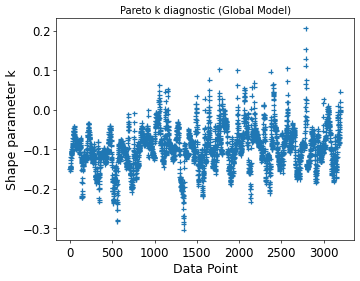

In [3]:
# Eley-Rideal Model - 2nd step is RDS  
with pm.Model() as ER_2:
    '''
    1. CO + * -> CO* 
    2. CO* + OH- -> COOH* + (e-) (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) 
    4. OH- + * -> OH* + (e-)
    '''
    # Priors
    deltaG1_0 = pm.Uniform('deltaG1_0', lower=-0.5, upper=0.1) 
    deltaG4_0 = pm.Uniform('deltaG4_0', lower=-0.4, upper=0.2) # at 0V_SHE
    beta_2 = pm.Uniform('beta_2', lower=0.05, upper=0.95)     
    Gact2_0 = pm.Uniform('Gact2_0', lower=0, upper=2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO + term_OH)
    log_theta = - pm.math.logsumexp(pt.stack([zeros, term_CO+zeros, term_OH+zeros]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pm.math.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pm.math.exp(log_theta_OH))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + np.log(C_KOH_in)
    alpha, delta_OH, delta_CO, rate = observables(log_rate)

trace_ER_2, loo_ER_2 = fit_and_evaluate(ER_2)

Kinetic Parameters found: ['deltaG1_0', 'deltaG4_0', 'beta_2', 'Gact2_0']
            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0 -0.127  0.001  -0.129   -0.124        0.0      0.0    1341.0    1890.0    1.0
deltaG4_0 -0.035  0.002  -0.039   -0.031        0.0      0.0    1251.0    1645.0    1.0
beta_2     0.288  0.003   0.282    0.294        0.0      0.0    1316.0    1580.0    1.0
Gact2_0    1.272  0.000   1.271    1.272        0.0      0.0    1803.0    2321.0    1.0


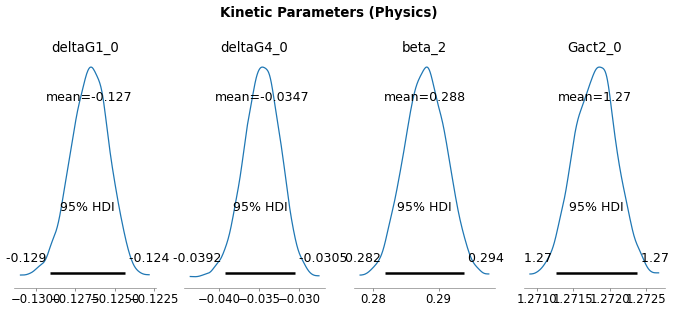

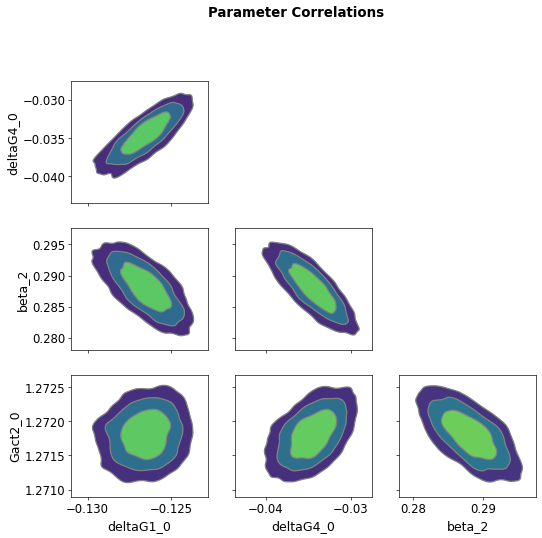

Sampling: [rate]


rate: 0.806


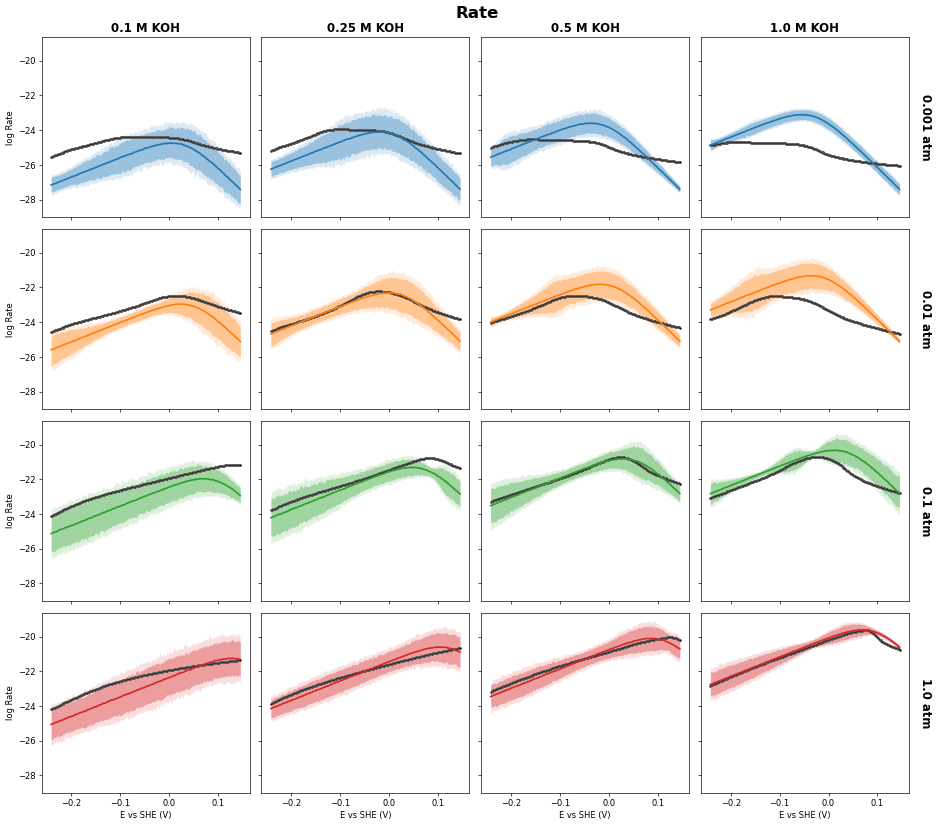

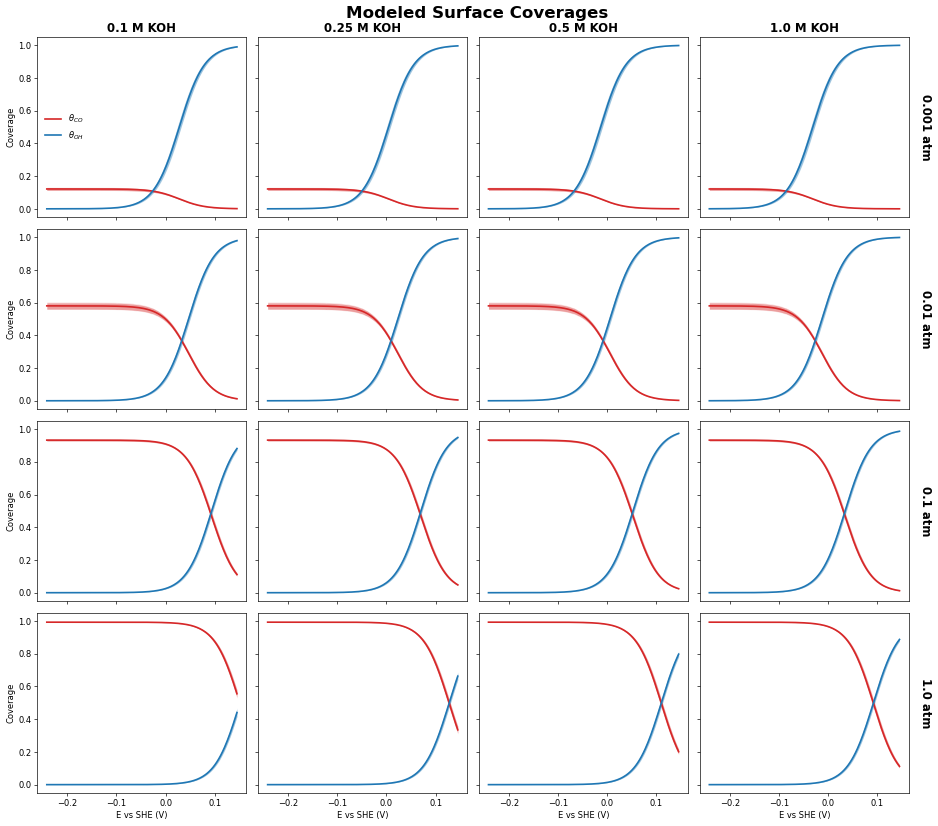

In [4]:
ppc_ER_2 = plot_posteriors(trace_ER_2, ER_2)
plot_model_fits(ppc_ER_2); plot_coverages(trace_ER_2)

# ER 3

# LH 3

# ER 2 3 - Series RDS

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.10,63
,2000,0,0.11,107
,2000,0,0.11,159
,2000,0,0.10,31


Computed from 4000 posterior samples and 3200 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -2752.16    79.80
p_loo       15.53        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     3200  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



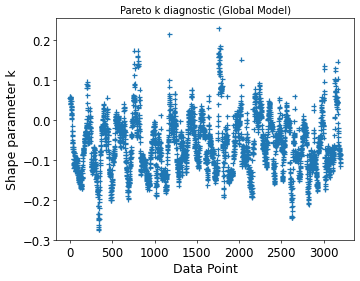

In [17]:
# Eley-Rideal Model - 2nd and 3rd steps are RDS 
with pm.Model() as ER_2_3:
    '''
    1. CO + * -> CO* 
    2. CO* + OH- -> COOH* + (e-) (RDS) (Reversible)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (RDS)
    4. OH- + * -> OH* + (e-)
    '''
    # Priors
    deltaG1_0 = pm.Uniform('deltaG1_0', lower=-0.5, upper=0.1) 
    deltaG4_0 = pm.Uniform('deltaG4_0', lower=-0.4, upper=0.2) # at 0V_SHE
    deltaG2_0 = pm.Normal('deltaG2_0', mu=0, sigma=0.5) # at 0V_SHE
    beta_2 = pm.Uniform('beta_2', lower=0.05, upper=0.95)
    beta_3 = pm.Uniform('beta_3', lower=0.05, upper=0.95)
    Gact2_0 = pm.Uniform('Gact2_0', lower=0, upper=2) # at 0V_SHE
    Gact3_0 = pm.Uniform('Gact3_0', lower=0, upper=2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG2 = deltaG2_0 - E_in
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    Gact3 = Gact3_0 - beta_3*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K2 = -deltaG2/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    log_k3 = np.log(kb_J*T/h) - Gact3/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    term_COOH = log_k2 + term_CO + np.log(C_KOH_in) - pm.math.logaddexp(log_k2 - log_K2, log_k3 + np.log(C_KOH_in))
    zeros = pt.zeros_like(term_CO + term_OH)
    log_theta = - pm.math.logsumexp(pt.stack([zeros, term_CO+zeros, term_OH+zeros, term_COOH+zeros]), axis=0) 
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta
    log_theta_COOH = term_COOH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pm.math.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pm.math.exp(log_theta_OH))

    # Rate expression
    log_rate = log_k3 + log_theta_COOH + np.log(C_KOH_in)
    alpha, delta_OH, delta_CO, rate = observables(log_rate)

trace_ER_2_3, loo_ER_2_3 = fit_and_evaluate(ER_2_3)

Kinetic Parameters found: ['deltaG2_0', 'deltaG1_0', 'deltaG4_0', 'beta_2', 'beta_3', 'Gact2_0', 'Gact3_0']
            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG2_0 -0.712  0.224  -1.127   -0.413      0.007    0.007    1321.0    1111.0    1.0
deltaG1_0 -0.168  0.007  -0.182   -0.155      0.000    0.000     639.0     864.0    1.0
deltaG4_0 -0.278  0.005  -0.288   -0.269      0.000    0.000     716.0    1108.0    1.0
beta_2     0.876  0.003   0.871    0.881      0.000    0.000    2091.0    2658.0    1.0
beta_3     0.248  0.004   0.240    0.256      0.000    0.000    1558.0    2267.0    1.0
Gact2_0    1.117  0.003   1.110    1.123      0.000    0.000     871.0    1060.0    1.0
Gact3_0    1.270  0.000   1.269    1.270      0.000    0.000    3433.0    2960.0    1.0


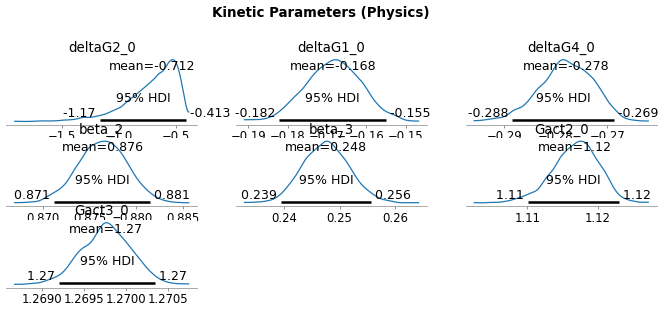

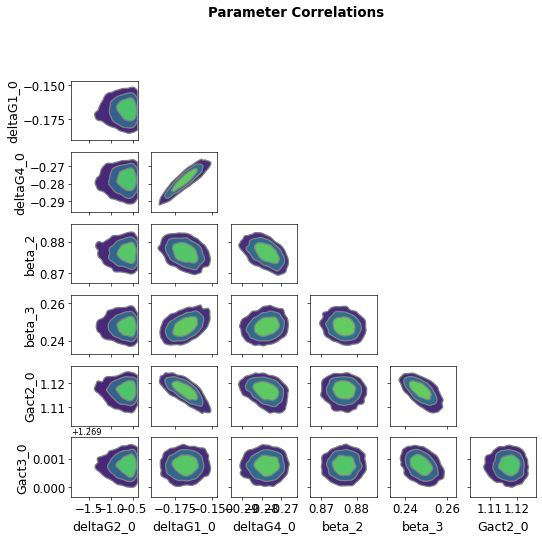

Sampling: [rate]


rate: 0.858


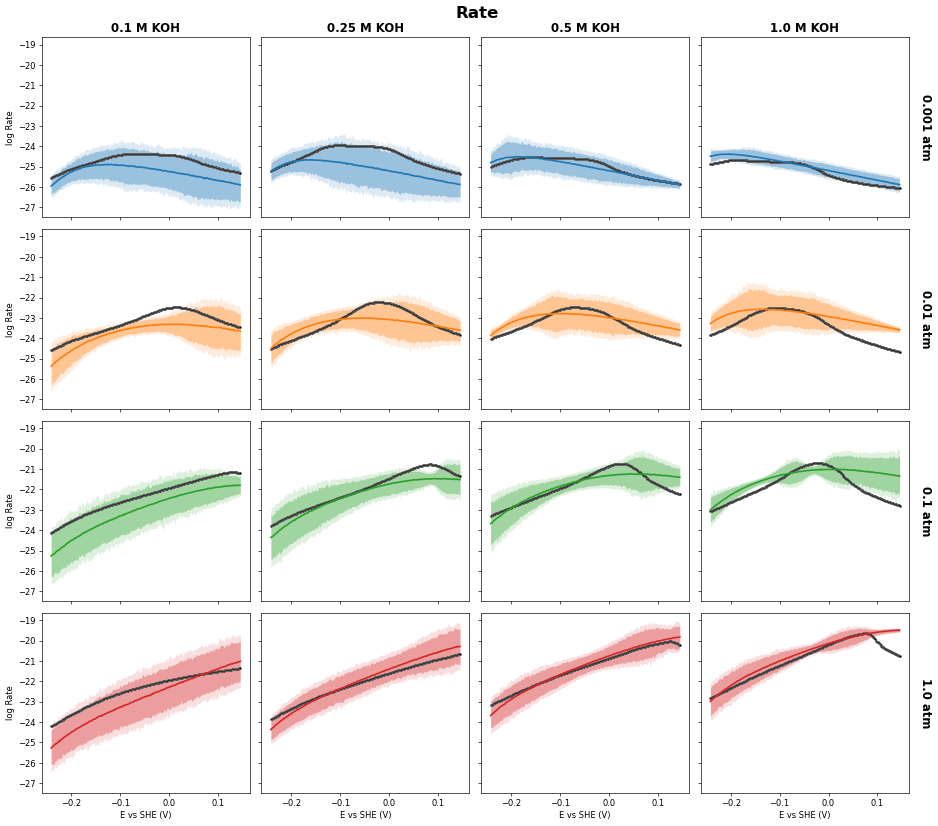

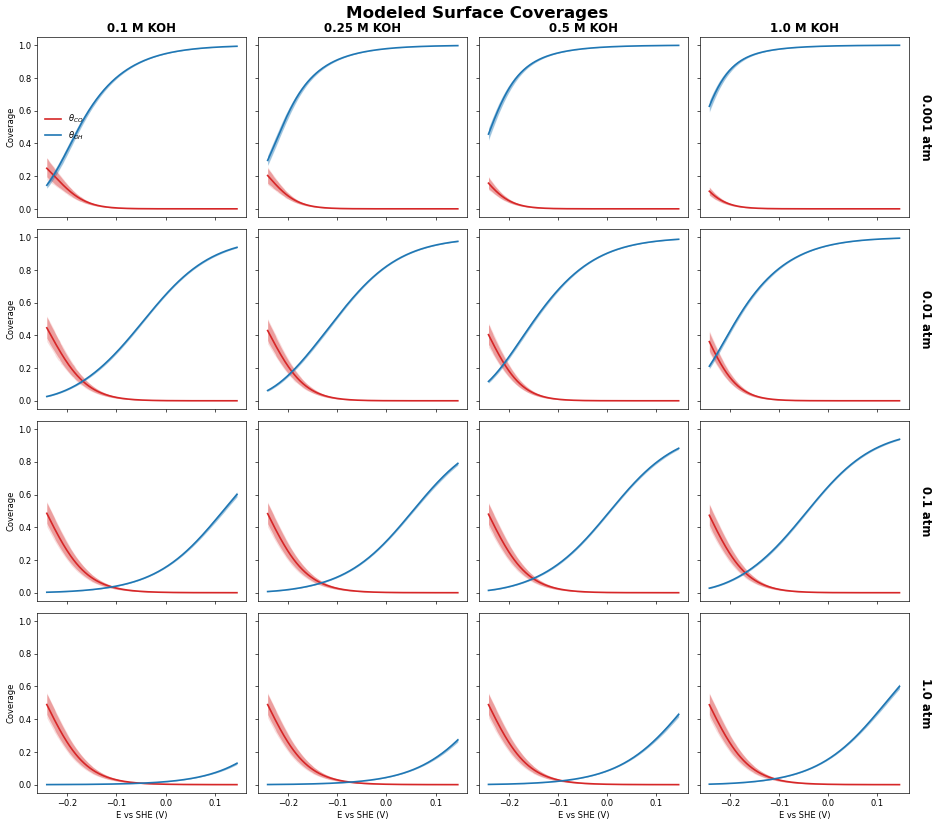

In [18]:
ppc_ER_2_3 = plot_posteriors(trace_ER_2_3, ER_2_3)
plot_model_fits(ppc_ER_2_3); plot_coverages(trace_ER_2_3)

# ER 2 + LH 2 - Parallel RDS

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.34,15
,2000,0,0.37,15
,2000,0,0.35,15
,2000,0,0.33,15


Computed from 4000 posterior samples and 3200 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -4425.65   113.10
p_loo       19.03        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     3200  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



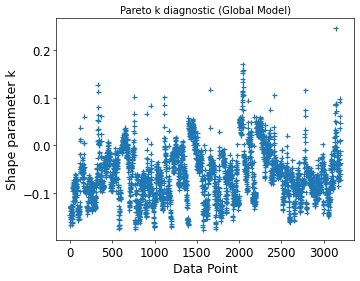

In [11]:
# Eley-Rideal + Langmuir-Hinshelwood Hybrid Model - 2nd step is RDS
with pm.Model() as ER_LH_2:
    '''
    1. CO + * -> CO* 
    2a. CO* + OH- -> COOH* + (e-) (RDS)
    2b. CO* + OH* -> COOH* + * (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) 
    4. OH- + * -> OH* + (e-)
    '''
    # Priors
    deltaG1_0 = pm.Uniform('deltaG1_0', lower=-0.5, upper=0.1) 
    deltaG4_0 = pm.Uniform('deltaG4_0', lower=-0.4, upper=0.2) # at 0V_SHE
    beta_2 = pm.Uniform('beta_2', lower=0.05, upper=0.95)
    Gact2_0_LH = pm.Uniform('Gact2_0_LH', lower=0, upper=2)
    Gact2_0_ER = pm.Uniform('Gact2_0_ER', lower=0, upper=2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2_LH = Gact2_0_LH
    Gact2_ER = Gact2_0_ER - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO + term_OH)
    log_theta = - pm.math.logsumexp(pt.stack([zeros, term_CO+zeros, term_OH+zeros]), axis=0) 
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pm.math.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pm.math.exp(log_theta_OH))

    # Rate expression
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH
    log_rate = pm.math.logaddexp(log_rate_ER, log_rate_LH)
    alpha, delta_OH, delta_CO, rate = observables(log_rate)

trace_ER_LH_2, loo_ER_LH_2 = fit_and_evaluate(ER_LH_2)

Kinetic Parameters found: ['deltaG1_0', 'deltaG4_0', 'beta_2', 'Gact2_0_LH', 'Gact2_0_ER']
             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.116  0.001  -0.118   -0.115        0.0      0.0    1262.0    1804.0    1.0
deltaG4_0  -0.030  0.001  -0.032   -0.028        0.0      0.0    1221.0    1849.0    1.0
beta_2      0.256  0.003   0.251    0.262        0.0      0.0    1216.0    1837.0    1.0
Gact2_0_LH  1.285  0.001   1.283    1.288        0.0      0.0    1742.0    2386.0    1.0
Gact2_0_ER  1.274  0.000   1.273    1.274        0.0      0.0    1745.0    2364.0    1.0


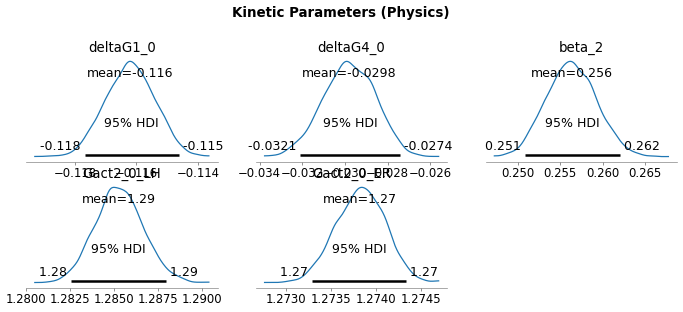

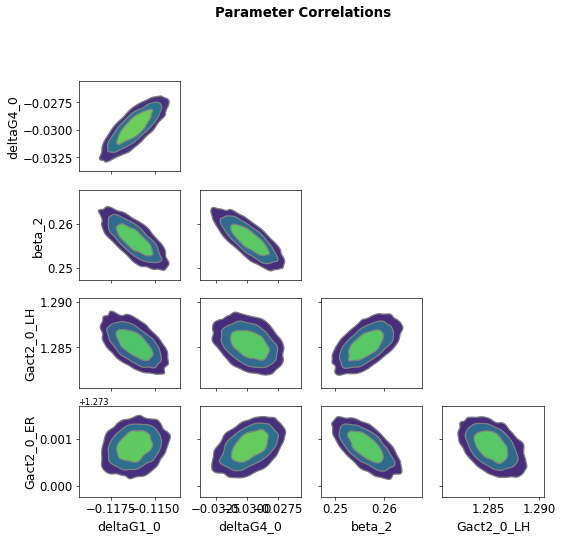

Sampling: [rate]


rate: 0.808


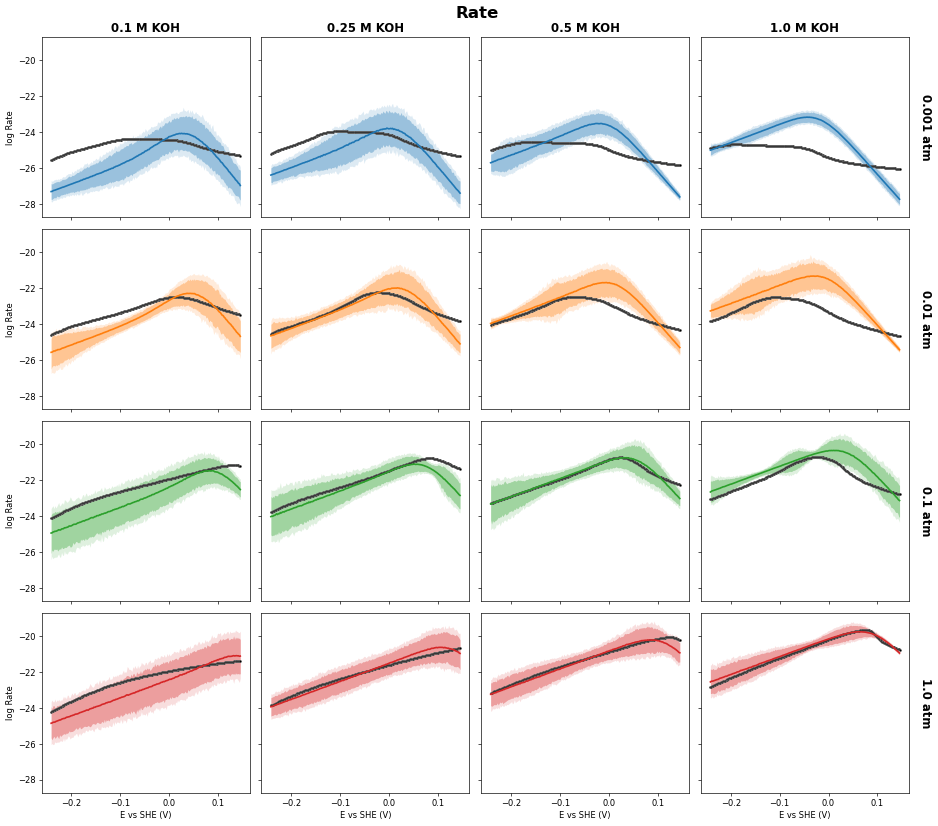

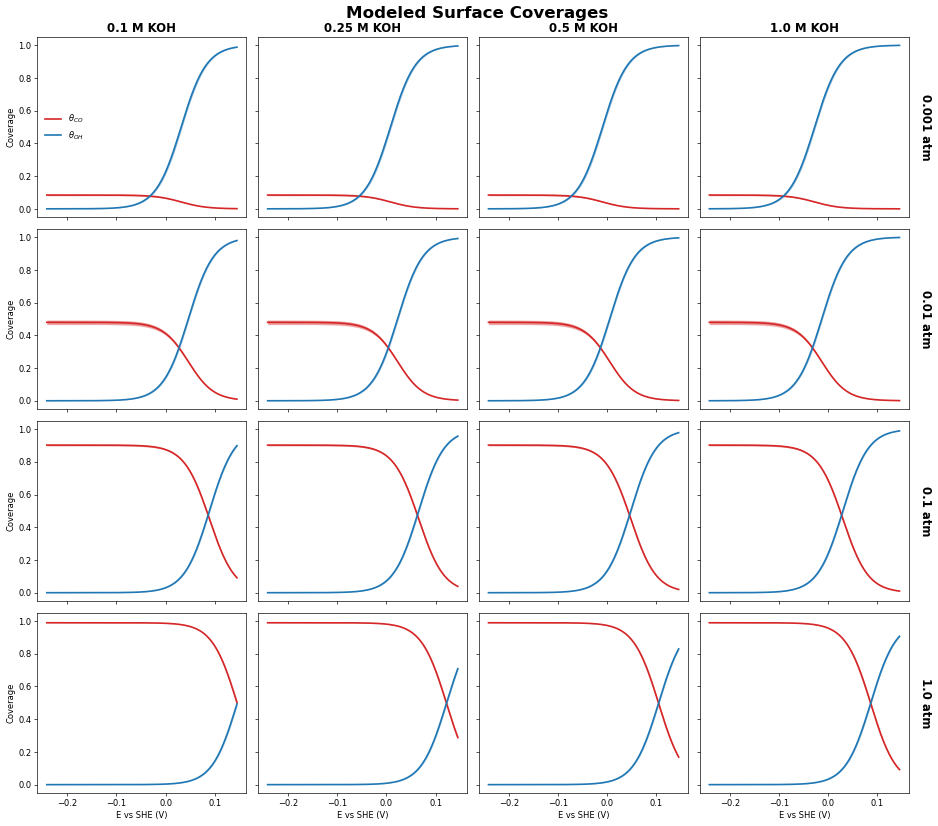

In [12]:
ppc_ER_LH_2 = plot_posteriors(trace_ER_LH_2, ER_LH_2)
plot_model_fits(ppc_ER_LH_2); plot_coverages(trace_ER_LH_2)

# ER 2 + LH 2 + 3 - Series and Parallel RDS

In [13]:
# Helper functions 

def quadratic_solve(a, b, c): 
    max_val = pt.maximum(pt.abs(a), pt.maximum(pt.abs(b), pt.abs(c)))
    a_n = a / max_val; b_n = b / max_val; c_n = c / max_val
    discriminant = pt.sqr(b_n) - 4 * a_n *c_n
    sqrt_disc = pt.sqrt(discriminant)
    root_pos = -2 * c_n / (b_n + sqrt_disc)
    root_neg = (sqrt_disc - b_n) / (2 * a_n)
    return pt.switch(pt.gt(b_n, 0), root_pos, root_neg)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.04,191
,2000,4,0.10,63
,2000,1,0.06,63
,2000,0,0.08,191


Computed from 4000 posterior samples and 3200 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -4699.21    94.05
p_loo     2554.45        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     3200  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



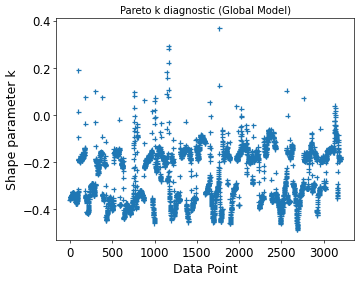

In [14]:
# Eley-Rideal + Langmuir-Hinshelwood Hybrid Model - 2nd and 3rd steps are RDS
with pm.Model() as ER_LH_2_3:
    '''
    1. CO + * -> CO* 
    2a. CO* + OH- -> COOH* + (e-) (RDS) (Reversible)
    2b. CO* + OH* -> COOH* + * (RDS) (Reversible)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (RDS)
    4. OH- + * -> OH* + (e-)
    '''
    # Priors
    deltaG1_0 = pm.Uniform('deltaG1_0', lower=-0.5, upper=0.1) 
    deltaG4_0 = pm.Uniform('deltaG4_0', lower=-0.4, upper=0.2) # at 0V_SHE
    deltaG2_LH_0 = pm.Normal('deltaG2_LH_0', mu=0, sigma=0.5) # at 0V_SHE
    deltaG2_ER_0 = deltaG2_LH_0 + deltaG4_0 # Hess' law
    beta_2 = pm.Uniform("beta_2", lower=0.05, upper=0.95)
    beta_3 = pm.Uniform("beta_3", lower=0.05, upper=0.95)
    Gact2_LH_0 = pm.Uniform('Gact2_LH_0', lower=0, upper=2)
    Gact2_ER_0 = pm.Uniform('Gact2_ER_0', lower=0, upper=2) # at 0V_SHE
    Gact3_0 = pm.Uniform('Gact3_0', lower=0, upper=2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG2_ER = deltaG2_ER_0 - E_in
    deltaG2_LH = deltaG2_LH_0
    deltaG4 = deltaG4_0 - E_in
    Gact2_LH = Gact2_LH_0
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact3 = Gact3_0 - beta_3*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K2_LH = -deltaG2_LH/(kb_eV*T)
    log_K2_ER = -deltaG2_ER/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k3 = np.log(kb_J*T/h) - Gact3/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)

    log_C_KOH = np.log(C_KOH_in)
    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + log_C_KOH

    zeros = pt.zeros_like(term_CO+term_OH)
    log_Z = pt.logsumexp(pt.stack([zeros, term_CO+zeros, term_OH+zeros]), axis=0); Z_term = pt.exp(log_Z)
    log_k2a_fwd = log_k2_ER + log_C_KOH; log_k2b_fwd = log_k2_LH
    log_k2a_rev = log_k2_ER - log_K2_ER; log_k2b_rev = log_k2_LH - log_K2_LH
    log_k3_fwd  = log_k3 + log_C_KOH
    log_R_sink = pt.logaddexp(log_k2a_rev, log_k3_fwd); R_sink = pt.exp(log_R_sink)
    log_a_quad = pt.logaddexp(log_k2b_fwd + term_CO + term_OH, log_Z + log_k2b_rev); a_quad = pt.exp(log_a_quad)
    b_quad = pt.exp(log_k2a_fwd + term_CO) + pt.exp(log_Z + log_R_sink) - pt.exp(log_k2b_rev)
    c_quad = -R_sink
    theta = quadratic_solve(a_quad, b_quad, c_quad)
    num_COOH = pt.exp(log_k2a_fwd + term_CO) * theta + pt.exp(log_k2b_fwd + term_CO + term_OH) * pt.sqr(theta)
    den_COOH = R_sink + pt.exp(log_k2b_rev) * theta
    theta_COOH = num_COOH / den_COOH

    theta_CO = pm.Deterministic('theta_CO', pt.exp(term_CO) * theta)
    theta_OH = pm.Deterministic('theta_OH', pt.exp(term_OH) * theta)

    log_rate = log_k3 + pt.log(theta_COOH) + log_C_KOH
    alpha, delta_OH, delta_CO, rate = observables(log_rate)
        
trace_ER_LH_2_3, loo_ER_LH_2_3 = fit_and_evaluate(ER_LH_2_3)

Kinetic Parameters found: ['deltaG2_LH_0', 'deltaG1_0', 'deltaG4_0', 'beta_2', 'beta_3', 'Gact2_LH_0', 'Gact2_ER_0', 'Gact3_0']
               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG2_LH_0 -0.445  0.337  -1.105    0.265      0.060    0.022      32.0      32.0   1.09
deltaG1_0    -0.155  0.024  -0.179   -0.115      0.011    0.006       7.0      32.0   1.54
deltaG4_0    -0.216  0.108  -0.286   -0.028      0.054    0.031       7.0      31.0   1.53
beta_2        0.721  0.269   0.253    0.881      0.134    0.077       7.0      36.0   1.53
beta_3        0.304  0.167   0.051    0.724      0.049    0.063      49.0      29.0   1.50
Gact2_LH_0    1.596  0.230   1.281    1.941      0.091    0.028       7.0      29.0   1.53
Gact2_ER_0    1.156  0.068   1.111    1.274      0.034    0.020       7.0      30.0   1.53
Gact3_0       1.065  0.385   0.185    1.271      0.178    0.118       7.0      37.0   1.53


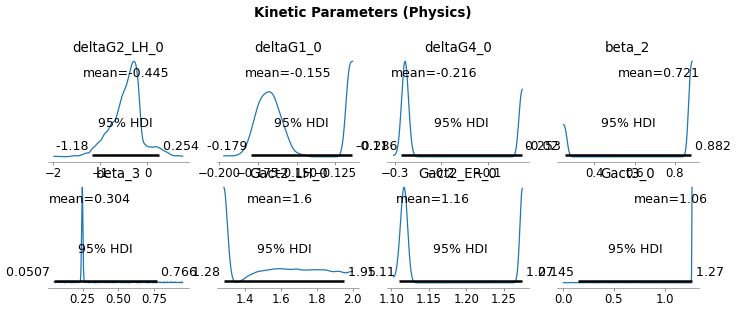

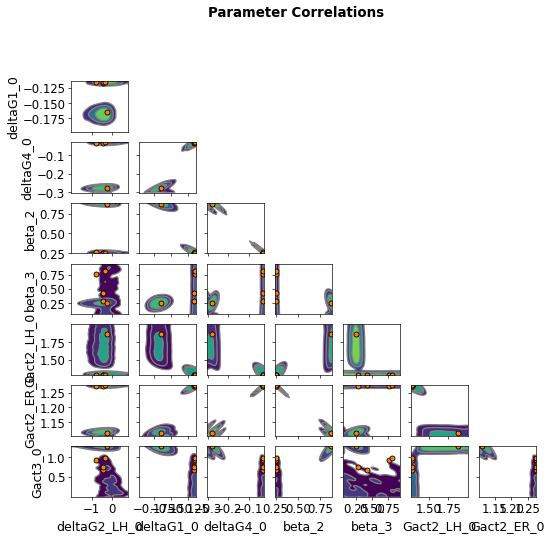

Sampling: [rate]


rate: 0.845


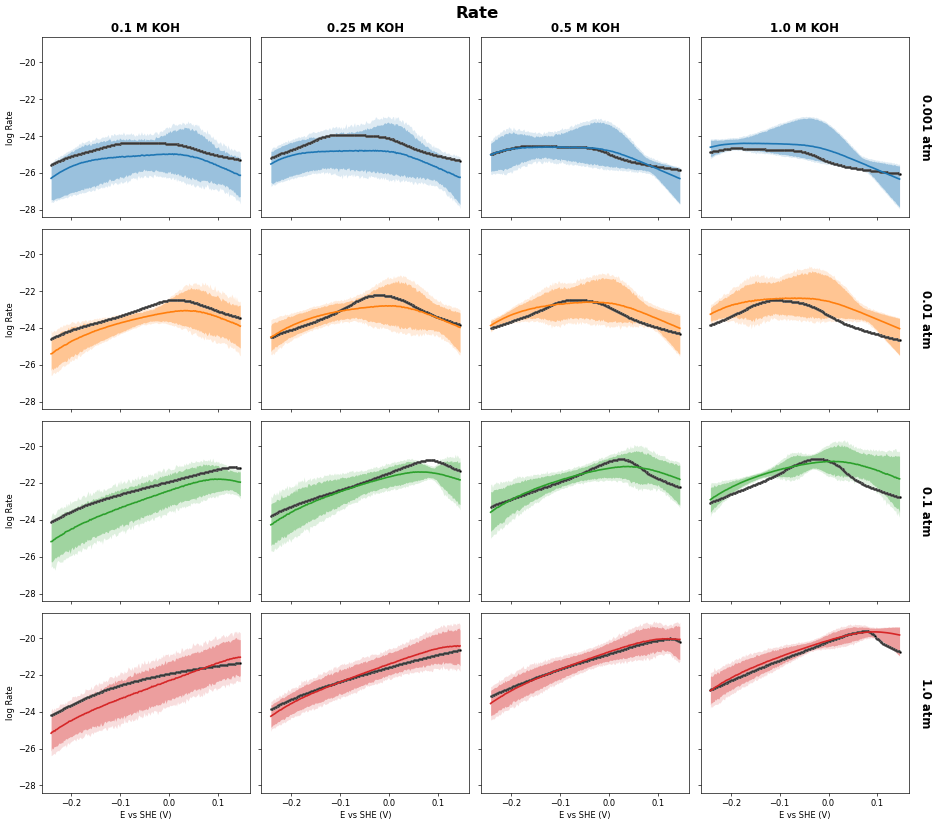

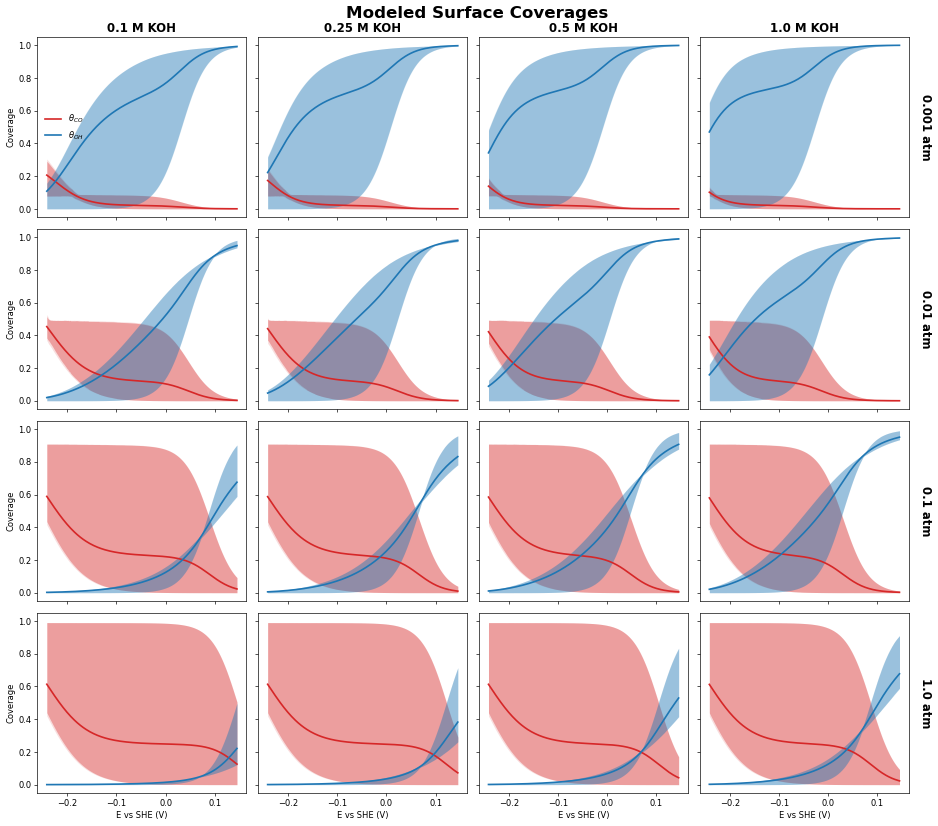

In [15]:
ppc_ER_LH_2_3 = plot_posteriors(trace_ER_LH_2_3, ER_LH_2_3)
plot_model_fits(ppc_ER_LH_2_3); plot_coverages(trace_ER_LH_2_3)

# Comparison

           rank     elpd_loo        p_loo    elpd_diff        weight          se         dse  warning scale
ER_2_3        0 -2752.164097    15.529465     0.000000  6.385560e-01   79.796258    0.000000    False   log
ER_LH_2       1 -4425.654042    19.029987  1673.489945  3.445845e-01  113.095551  136.169421    False   log
ER_LH_2_3     2 -4699.209855  2554.448883  1947.045758  2.100396e-07   94.054061   81.848385    False   log
ER_2          3 -4802.924543    39.479035  2050.760446  1.685922e-02  110.024395  126.421542    False   log


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

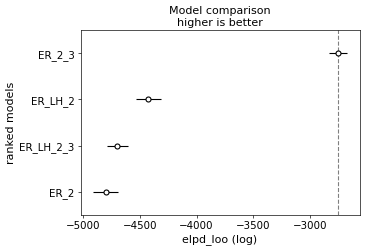

In [19]:

comparison_dict = {
    "ER_2": loo_ER_2, 
    # "LH_2": loo_LH_2, 
    # "ER_3": loo_ER_3, 
    # "LH_3": loo_LH_3, 
    "ER_2_3": loo_ER_2_3,  
    "ER_LH_2": loo_ER_LH_2, 
    "ER_LH_2_3": loo_ER_LH_2_3,

}
comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)